In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
df=pd.read_csv("/content/tbii-qazn-mt-balans-dt_bd_018.csv")

In [94]:
df

,Year,Unnamed: 1,İstehsal,İdxal,İxrac,Ehtiyatların dəyişməsi,Ümumi enerji təchizatı,Statistik fərq,Transformasiya sektorunun məsrəfi,Energetika sektorunun daxili istehlakı,İtkilər,Son istehlak
0,2024,NaN,38608.1,-,-26085.5,749.8,13272.4,7.0,5397.1,332.5,977.1,6558.7
1,2023,NaN,36414.4,2872.0,-24933.5,-11.9,14341.0,7.7,6605.2,340.1,365.3,7022.7
2,2022,NaN,34955.5,1554.0,-22634.9,69.3,13943.9,8.6,6553.3,252.3,498.6,6631.1
3,2021,NaN,32578.3,-,-19078.4,-374.0,13125.9,13.9,6316.2,265.2,698.8,5831.8
4,2020,NaN,26487.3,-,-13839.9,17.0,12664.4,29.4,6110.8,271.9,667.0,5585.3
5,2019,NaN,24514.3,-,-11833.0,-126.7,12554.6,22.1,6170.6,498.7,720.8,5142.4
6,2018,NaN,19207.1,1798.2,-9911.8,-17.4,11076.1,14.5,6166.3,477.7,580.8,3836.8
7,2017,NaN,18186.0,2109.9,-8856.9,-566.9,10872.1,15.6,5667.9,490.0,769.0,3929.6
8,2016,NaN,18717.6,298.4,-8049.1,226.8,11193.7,20.7,5258.8,436.9,804.8,4672.5
9,2015,NaN,19236.1,-,-8145.2,323.9,11414.8,45.7,5639.2,503.0,1087.0,4139.9


In [95]:
df.shape

(18, 12)

In [96]:
import chardet
with open("/content/tbii-qazn-mt-balans-dt_bd_018.csv", 'rb') as rawdata:
    result = chardet.detect(rawdata.read())

In [97]:
result

{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}

In [98]:
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_18471/173857299.py:1: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [99]:
df.drop_duplicates(inplace=True)

In [100]:
df.isna().sum()

,0
Year,0
Unnamed: 1,18
İstehsal,0
İdxal,0
İxrac,0
Ehtiyatların dəyişməsi,0
Ümumi enerji təchizatı,0
Statistik fərq,0
Transformasiya sektorunun məsrəfi,0
Energetika sektorunun daxili istehlakı,0


In [101]:
df.drop("Unnamed: 1", axis=1, inplace=True)

In [102]:
df

,Year,İstehsal,İdxal,İxrac,Ehtiyatların dəyişməsi,Ümumi enerji təchizatı,Statistik fərq,Transformasiya sektorunun məsrəfi,Energetika sektorunun daxili istehlakı,İtkilər,Son istehlak
0,2024,38608.1,-,-26085.5,749.8,13272.4,7.0,5397.1,332.5,977.1,6558.7
1,2023,36414.4,2872.0,-24933.5,-11.9,14341.0,7.7,6605.2,340.1,365.3,7022.7
2,2022,34955.5,1554.0,-22634.9,69.3,13943.9,8.6,6553.3,252.3,498.6,6631.1
3,2021,32578.3,-,-19078.4,-374.0,13125.9,13.9,6316.2,265.2,698.8,5831.8
4,2020,26487.3,-,-13839.9,17.0,12664.4,29.4,6110.8,271.9,667.0,5585.3
5,2019,24514.3,-,-11833.0,-126.7,12554.6,22.1,6170.6,498.7,720.8,5142.4
6,2018,19207.1,1798.2,-9911.8,-17.4,11076.1,14.5,6166.3,477.7,580.8,3836.8
7,2017,18186.0,2109.9,-8856.9,-566.9,10872.1,15.6,5667.9,490.0,769.0,3929.6
8,2016,18717.6,298.4,-8049.1,226.8,11193.7,20.7,5258.8,436.9,804.8,4672.5
9,2015,19236.1,-,-8145.2,323.9,11414.8,45.7,5639.2,503.0,1087.0,4139.9


In [103]:
stcol = df.select_dtypes(include=['object']).columns
a = 0
for col in stcol:
    a+=(df[col]=='-').sum()
    df[col] = df[col].replace('-', '0').astype(float)

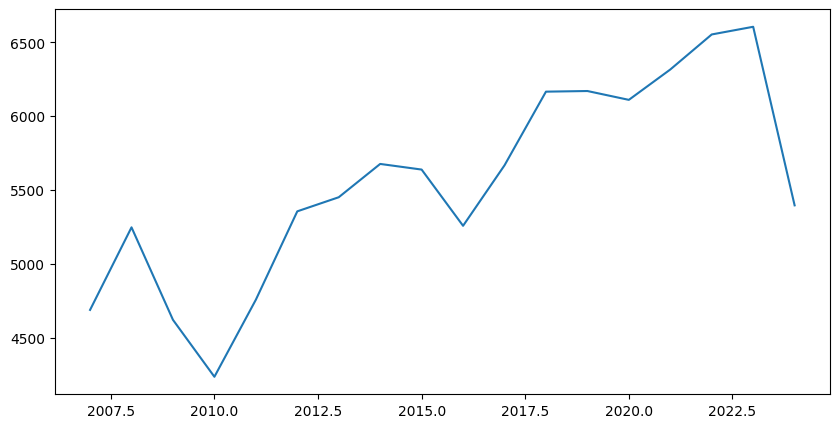

In [104]:
plt.figure(figsize=(10, 5))
plt.plot(df['Year'], df['Transformasiya sektorunun məsrəfi'])

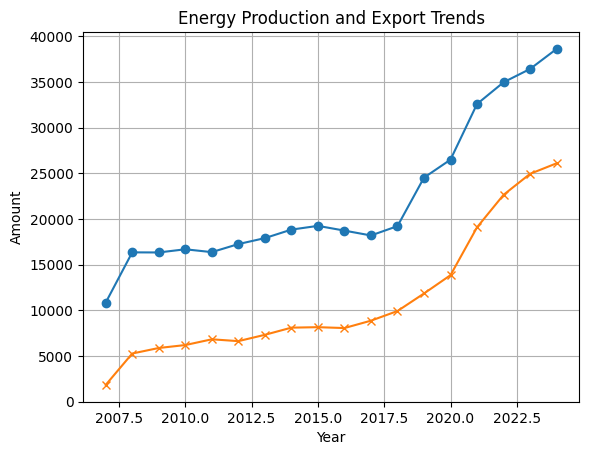

In [107]:
plt.plot(df['Year'], df['İstehsal'], marker='o')
plt.plot(df['Year'], df['İxrac'].abs(), marker='x')
plt.title('Energy Production and Export Trends')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.grid()

Text(0.5, 1.0, 'Metric Correlation Heatmap')

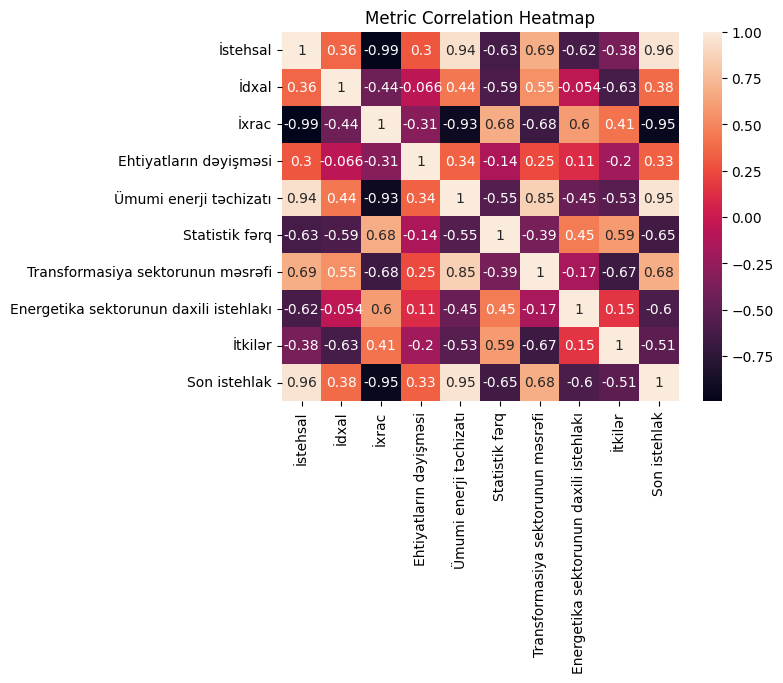

In [108]:
sns.heatmap(df.drop(columns=['Year']).corr(), annot=True)
plt.title('Metric Correlation Heatmap')

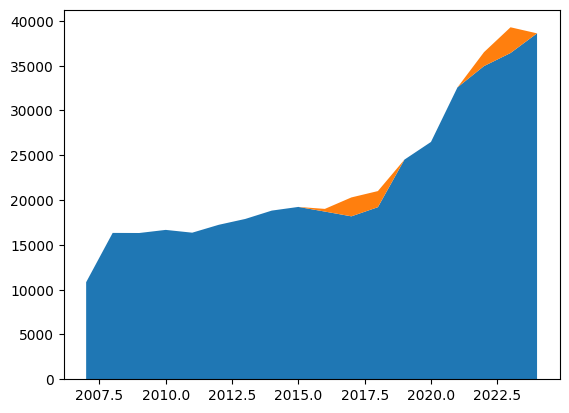

In [109]:
plt.stackplot(df['Year'], df['İstehsal'], df['İdxal'], labels=['Production', 'Import'])